In [1]:
import pandas as pd

# Load the dataset to inspect its structure
file_path = 'Epileptic Seizure Recognition.csv'
dataset = pd.read_csv(file_path)

# Display the first few rows and basic info about the dataset
dataset_info = dataset.info()
dataset_head = dataset.head()

dataset_info, dataset_head


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


(None,
       Unnamed   X1   X2   X3   X4   X5   X6   X7   X8   X9  ...  X170  X171  \
 0  X21.V1.791  135  190  229  223  192  125   55   -9  -33  ...   -17   -15   
 1  X15.V1.924  386  382  356  331  320  315  307  272  244  ...   164   150   
 2     X8.V1.1  -32  -39  -47  -37  -32  -36  -57  -73  -85  ...    57    64   
 3   X16.V1.60 -105 -101  -96  -92  -89  -95 -102 -100  -87  ...   -82   -81   
 4   X20.V1.54   -9  -65  -98 -102  -78  -48  -16    0  -21  ...     4     2   
 
    X172  X173  X174  X175  X176  X177  X178  y  
 0   -31   -77  -103  -127  -116   -83   -51  4  
 1   146   152   157   156   154   143   129  1  
 2    48    19   -12   -30   -35   -35   -36  5  
 3   -80   -77   -85   -77   -72   -69   -65  5  
 4   -12   -32   -41   -65   -83   -89   -73  5  
 
 [5 rows x 180 columns])

# Data Preparation

In [2]:
# Step 1: Data Preparation

# Remove the identifier column (first column)
dataset_cleaned = dataset.iloc[:, 1:]

# Separate features and labels
features = dataset_cleaned.iloc[:, :-1]
labels = dataset_cleaned.iloc[:, -1]

# Normalize the feature columns to have mean 0 and standard deviation 1
features_normalized = (features - features.mean()) / features.std()

# Combine normalized features and labels into a single dataframe for further processing
dataset_processed = pd.concat([features_normalized, labels], axis=1)

# Check the processed dataset structure
dataset_processed.head()


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,0.885013,1.209876,1.462701,1.439477,1.242312,0.818227,0.380894,-0.014266,-0.163189,-0.198406,...,-0.041629,-0.020281,-0.107126,-0.375726,-0.535921,-0.693828,-0.634116,-0.433272,-0.235389,4
1,2.400473,2.366087,2.239344,2.109165,2.037353,1.995946,1.941576,1.719027,1.546336,1.484504,...,1.057654,0.972799,0.942982,0.982869,1.018570,1.029250,1.023385,0.954199,0.856499,1
2,-0.123281,-0.169147,-0.225122,-0.172736,-0.149010,-0.179736,-0.312743,-0.409038,-0.484110,-0.547454,...,0.407802,0.455194,0.361566,0.193816,0.008151,-0.103232,-0.136866,-0.138587,-0.144398,5
3,-0.564033,-0.542507,-0.524771,-0.513781,-0.503051,-0.545449,-0.591436,-0.575582,-0.496453,-0.453959,...,-0.436398,-0.417513,-0.397834,-0.375726,-0.428302,-0.389397,-0.364005,-0.347322,-0.320314,5
4,0.015586,-0.325717,-0.537002,-0.575789,-0.434727,-0.254118,-0.058822,0.041248,-0.089130,-0.329299,...,0.085912,0.082037,0.005597,-0.108754,-0.165235,-0.316334,-0.431533,-0.470107,-0.368842,5


# Define Data Augmentation Functions for Tabular Data

In [3]:
import numpy as np

# Step 2: Define Data Augmentation Functions for Tabular Data

def add_noise(data, noise_level=0.1):
    """Add Gaussian noise to the data."""
    noise = np.random.normal(loc=0.0, scale=noise_level, size=data.shape)
    return data + noise

def shuffle_features(data):
    """Randomly shuffle the order of features."""
    shuffled_data = data.copy()
    for i in range(shuffled_data.shape[0]):
        np.random.shuffle(shuffled_data[i, :])
    return shuffled_data

def scale_values(data, scale_factor=0.1):
    """Scale values randomly by a factor."""
    scaling = np.random.uniform(1 - scale_factor, 1 + scale_factor, size=data.shape)
    return data * scaling

# Example: Apply augmentations to a batch of data (features only)
sample_data = features_normalized.values[:5, :]
augmented_data_1 = add_noise(sample_data, noise_level=0.05)
augmented_data_2 = shuffle_features(sample_data)
augmented_data_3 = scale_values(sample_data, scale_factor=0.1)

# Display examples of augmented data
augmented_data_1[:2], augmented_data_2[:2], augmented_data_3[:2]


(array([[ 8.90895550e-01,  1.13686747e+00,  1.52721174e+00,
          1.48699498e+00,  1.28513613e+00,  8.57024975e-01,
          2.51912569e-01, -3.46029312e-02, -1.05091932e-01,
         -1.93752148e-01, -3.61865355e-02,  2.15580825e-01,
          4.60264463e-01,  7.81421943e-01,  9.63889357e-01,
          1.00057031e+00,  7.74490270e-01,  4.21971386e-01,
         -3.04285463e-01, -7.16101377e-01, -8.16292454e-01,
         -7.12765541e-01, -6.04745677e-01, -1.72919543e-01,
          4.06617880e-02,  3.59395699e-01,  1.82098909e-01,
          4.35182482e-01,  4.01798226e-01,  3.24574461e-01,
          1.49990493e-01, -1.40430213e-01, -3.08145475e-01,
         -5.33923096e-01, -5.63037037e-01, -7.79922020e-01,
         -6.74226507e-01, -6.57024760e-01, -3.24086897e-01,
         -6.57649307e-02,  2.64802796e-01,  1.00823725e-01,
          9.03664924e-02,  5.20243189e-02,  5.90298817e-02,
          1.38885929e-01, -1.10802191e-01, -3.10687994e-01,
         -1.00090233e-01,  5.50380074e-0

# SimCLR-like Framework - Define the Encoder Network

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Step 3: SimCLR-like Framework - Define the Encoder Network
def create_encoder(input_dim):
    """Defines a simple encoder network."""
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(64, activation='relu')
    ])
    return model

# Step 4: Define the Projection Head
def create_projection_head(input_dim):
    """Defines the projection head network."""
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(32)  # Project to a smaller dimension
    ])
    return model

# Step 5: Prepare Augmented Views of Data for SimCLR
def generate_augmented_views(data, num_views=2):
    """Generate multiple augmented views for each sample."""
    augmented_views = []
    for _ in range(num_views):
        augmented_view = add_noise(data, noise_level=0.05)
        augmented_view = scale_values(augmented_view, scale_factor=0.1)
        augmented_views.append(augmented_view)
    return augmented_views

# Initialize the encoder and projection head
input_dim = features_normalized.shape[1]
encoder = create_encoder(input_dim)
projection_head = create_projection_head(64)  # Output of encoder is 64

# Generate augmented views
num_views = 2
augmented_views = generate_augmented_views(features_normalized.values, num_views=num_views)

# Display shapes of augmented views to verify
[view.shape for view in augmented_views]


2025-01-07 23:13:25.630056: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-07 23:13:26.015058: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-07 23:13:26.015141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-07 23:13:26.085424: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-07 23:13:26.228206: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-07 23:13:26.231147: I tensorflow/core/platform/cpu_feature_guard.cc:1

[(11500, 178), (11500, 178)]

# Generate Augmented Views

In [5]:
def generate_augmented_views(data, num_views=2):
    """Generate multiple augmented views for each sample."""
    augmented_views = []
    for _ in range(num_views):
        augmented_view = add_noise(data, noise_level=0.05)
        augmented_view = scale_values(augmented_view, scale_factor=0.1)
        augmented_views.append(augmented_view)
    return augmented_views

# Generate augmented views
augmented_views = generate_augmented_views(features_normalized.values, num_views=2)


# Train the Encoder and Projection Head

In [6]:
import tensorflow.keras.backend as K

# Define the contrastive loss
def contrastive_loss(z_i, z_j, temperature=0.5):
    """Contrastive loss function."""
    batch_size = tf.shape(z_i)[0]
    z = tf.concat([z_i, z_j], axis=0)
    z = tf.math.l2_normalize(z, axis=1)

    similarity_matrix = tf.matmul(z, z, transpose_b=True)
    logits = similarity_matrix / temperature

    labels = tf.concat([tf.range(batch_size), tf.range(batch_size)], axis=0)
    labels = tf.one_hot(labels, depth=2 * batch_size)

    loss = tf.nn.softmax_cross_entropy_with_logits(labels, logits)
    return tf.reduce_mean(loss)

# Define training loop
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
epochs = 10


for epoch in range(epochs):
    with tf.GradientTape() as tape:
        z_i = projection_head(encoder(augmented_views[0]))
        z_j = projection_head(encoder(augmented_views[1]))
        loss = contrastive_loss(z_i, z_j)

    gradients = tape.gradient(loss, encoder.trainable_variables + projection_head.trainable_variables)
    optimizer.apply_gradients(zip(gradients, encoder.trainable_variables + projection_head.trainable_variables))

    print(f"Epoch {epoch + 1}, Loss: {loss.numpy()}")


2025-01-07 23:13:37.312311: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2116000000 exceeds 10% of free system memory.
2025-01-07 23:13:37.713560: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2116000000 exceeds 10% of free system memory.
2025-01-07 23:13:37.987395: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2116000000 exceeds 10% of free system memory.
2025-01-07 23:13:38.201817: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2116000000 exceeds 10% of free system memory.
2025-01-07 23:13:40.667865: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 2116000000 exceeds 10% of free system memory.


Epoch 1, Loss: 9.260822296142578
Epoch 2, Loss: 8.964868545532227
Epoch 3, Loss: 8.713823318481445
Epoch 4, Loss: 8.567209243774414
Epoch 5, Loss: 8.48455810546875
Epoch 6, Loss: 8.424126625061035
Epoch 7, Loss: 8.377211570739746
Epoch 8, Loss: 8.34868049621582
Epoch 9, Loss: 8.338510513305664
Epoch 10, Loss: 8.339193344116211


# Evaluate Representations

In [7]:
# Freeze the encoder and add a classification head
encoder.trainable = False
classification_model = models.Sequential([
    encoder,
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')  # Adjust output layer for your task
])

classification_model.compile(optimizer='adam',
                             loss='binary_crossentropy',
                             metrics=['accuracy'])

# Train the classification model
classification_model.fit(features_normalized, labels, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10
288/288 [==============================] - 2s 4ms/step - loss: -13.6842 - accuracy: 0.0302 - val_loss: -26.5922 - val_accuracy: 0.0235
Epoch 2/10
288/288 [==============================] - 1s 3ms/step - loss: -87.3546 - accuracy: 0.0330 - val_loss: -178.9761 - val_accuracy: 0.0378
Epoch 3/10
288/288 [==============================] - 1s 3ms/step - loss: -239.6713 - accuracy: 0.0317 - val_loss: -389.2283 - val_accuracy: 0.0374
Epoch 4/10
288/288 [==============================] - 1s 2ms/step - loss: -456.2866 - accuracy: 0.0338 - val_loss: -604.1827 - val_accuracy: 0.0322
Epoch 5/10
288/288 [==============================] - 1s 2ms/step - loss: -728.5725 - accuracy: 0.0368 - val_loss: -894.8082 - val_accuracy: 0.0352
Epoch 6/10
288/288 [==============================] - 1s 3ms/step - loss: -1049.7140 - accuracy: 0.0375 - val_loss: -1282.7947 - val_accuracy: 0.0400
Epoch 7/10
288/288 [==============================] - 1s 3ms/step - loss: -1423.7257 - accuracy: 0.0410 - val_los

# Visulization 

Epoch 1, Loss: 8.342079162597656
Epoch 2, Loss: 8.34326457977295
Epoch 3, Loss: 8.339909553527832
Epoch 4, Loss: 8.333026885986328
Epoch 5, Loss: 8.324141502380371
Epoch 6, Loss: 8.314703941345215
Epoch 7, Loss: 8.305734634399414
Epoch 8, Loss: 8.297739028930664
Epoch 9, Loss: 8.290821075439453
Epoch 10, Loss: 8.284878730773926


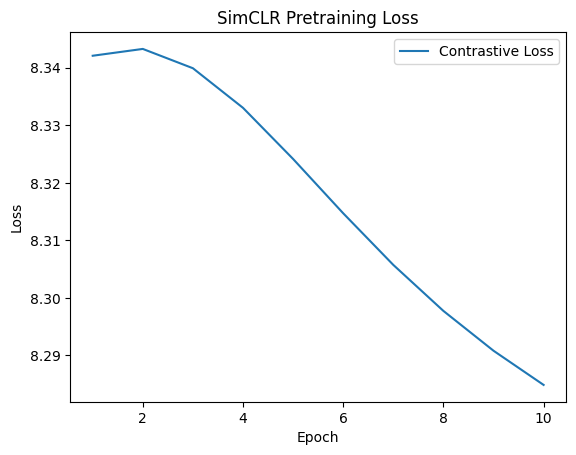

In [8]:
import matplotlib.pyplot as plt

# Initialize a list to track losses
losses = []
# Training loop for SimCLR with loss tracking
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        z_i = projection_head(encoder(augmented_views[0]))
        z_j = projection_head(encoder(augmented_views[1]))
        loss = contrastive_loss(z_i, z_j)
    gradients = tape.gradient(loss, encoder.trainable_variables + projection_head.trainable_variables)
    optimizer.apply_gradients(zip(gradients, encoder.trainable_variables + projection_head.trainable_variables))
    
    losses.append(loss.numpy())  # Track loss
    print(f"Epoch {epoch + 1}, Loss: {loss.numpy()}")

# Plot pretraining loss
plt.plot(range(1, epochs + 1), losses, label="Contrastive Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("SimCLR Pretraining Loss")
plt.legend()
plt.show()


Epoch 1/10
288/288 [==============================] - 2s 4ms/step - loss: -3337.7024 - accuracy: 0.0476 - val_loss: -3853.2627 - val_accuracy: 0.0474
Epoch 2/10
288/288 [==============================] - 1s 3ms/step - loss: -3923.3364 - accuracy: 0.0458 - val_loss: -4331.3608 - val_accuracy: 0.0439
Epoch 3/10
288/288 [==============================] - 1s 4ms/step - loss: -4531.4414 - accuracy: 0.0474 - val_loss: -5095.8423 - val_accuracy: 0.0491
Epoch 4/10
288/288 [==============================] - 1s 4ms/step - loss: -5174.8223 - accuracy: 0.0492 - val_loss: -5673.5469 - val_accuracy: 0.0452
Epoch 5/10
288/288 [==============================] - 1s 3ms/step - loss: -5856.9097 - accuracy: 0.0499 - val_loss: -6575.3193 - val_accuracy: 0.0496
Epoch 6/10
288/288 [==============================] - 1s 3ms/step - loss: -6576.3057 - accuracy: 0.0505 - val_loss: -7290.3267 - val_accuracy: 0.0504
Epoch 7/10
288/288 [==============================] - 1s 3ms/step - loss: -7312.5859 - accuracy: 0.0

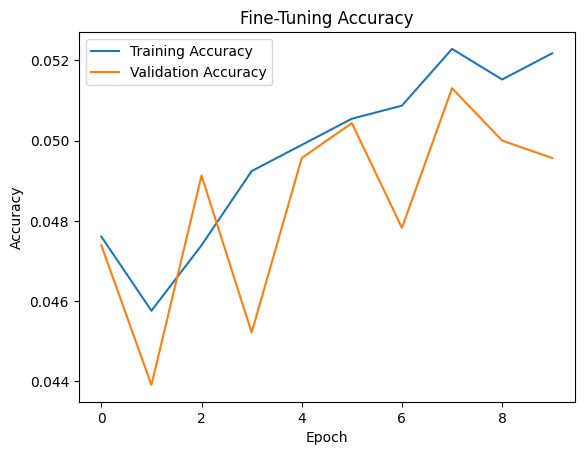

In [9]:
# Train the classification model with history tracking
history = classification_model.fit(features_normalized.values, labels.values,
                                    epochs=10, batch_size=32, validation_split=0.2)

# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Fine-Tuning Accuracy")
plt.legend()
plt.show()


360/360 [==============================] - 1s 2ms/step


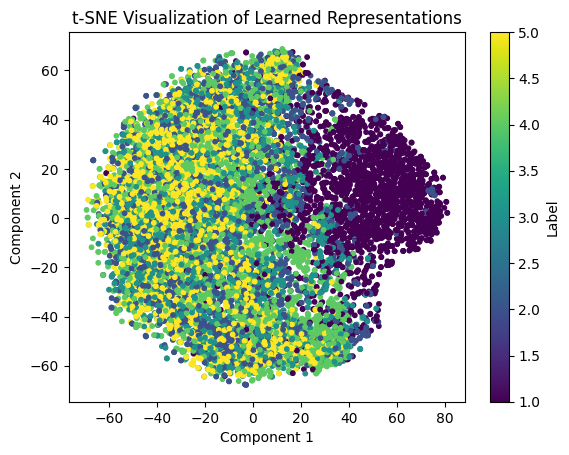

In [10]:
from sklearn.manifold import TSNE

# Get embeddings from encoder
embeddings = encoder.predict(features_normalized.values)

# Reduce dimensions for visualization
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(embeddings)

# Scatter plot of embeddings
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=labels.values, cmap='viridis', s=10)
plt.colorbar(label='Label')
plt.title("t-SNE Visualization of Learned Representations")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()
